In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-safesense-vi-videbert/final_train_data_v3_SEMANTIC.xlsx


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: Install Dependencies
# ═══════════════════════════════════════════════════════════════════════════════

!pip install transformers accelerate -q

import torch
print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: Import Libraries
# ═══════════════════════════════════════════════════════════════════════════════

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ PyTorch: 2.6.0+cu124
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 14.7 GB
✅ All libraries imported!


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Configuration (COMPLETE - FIX ALL ERRORS)
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import random
import numpy as np
import os

class Config:
    # Model - ViDeBERTa
    MODEL_NAME = "Fsoft-AIC/videberta-base"
    NUM_LABELS = 3
    MAX_LENGTH = 512  # ViDeBERTa supports longer context!
    
    # Training
    BATCH_SIZE = 8  # ← REDUCED for memory (was 16)
    GRADIENT_ACCUMULATION_STEPS = 4  # ← INCREASED (was 2) - effective batch = 32
    EPOCHS = 5
    LEARNING_RATE = 2e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    
    # Optimization
    USE_CLASS_WEIGHTS = True
    LABEL_SMOOTHING = 0.1
    
    # Early stopping
    PATIENCE = 2
    
    # Seed
    SEED = 42
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Paths
    DATA_PATH = None  # Will be set automatically
    OUTPUT_DIR = 'videberta_toxic_model'
    MODEL_SAVE_PATH = 'videberta_toxic_model'
    
    # Special tokens (CRITICAL for ViDeBERTa!)
    SPECIAL_TOKENS = [
        '<sep>',      # Semantic separator (title/comment boundary)
        '<emo_pos>',  # Positive emoji
        '<emo_neg>',  # Negative emoji
        '<person>',   # Person mention
        '<user>'      # User mention
    ]

# Set random seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.SEED)

# Create output directory
import os
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

print('='*80)
print('CONFIGURATION')
print('='*80)
print(f'🔧 Device: {Config.DEVICE}')
print(f'🔧 Model: {Config.MODEL_NAME}')
print(f'🔧 Max Length: {Config.MAX_LENGTH} tokens (2x PhoBERT!)')
print(f'🔧 Batch Size: {Config.BATCH_SIZE} x {Config.GRADIENT_ACCUMULATION_STEPS} = {Config.BATCH_SIZE * Config.GRADIENT_ACCUMULATION_STEPS}')
print(f'🔧 Epochs: {Config.EPOCHS}')
print(f'🔧 Learning Rate: {Config.LEARNING_RATE}')
print(f'🔧 Output Dir: {Config.OUTPUT_DIR}')
print(f'🔧 Special Tokens: {len(Config.SPECIAL_TOKENS)}')
print('✅ Configuration set!')


CONFIGURATION
🔧 Device: cuda
🔧 Model: Fsoft-AIC/videberta-base
🔧 Max Length: 512 tokens (2x PhoBERT!)
🔧 Batch Size: 8 x 4 = 32
🔧 Epochs: 5
🔧 Learning Rate: 2e-05
🔧 Output Dir: videberta_toxic_model
🔧 Special Tokens: 5
✅ Configuration set!


In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Find & Load Data
# ═══════════════════════════════════════════════════════════════════════════════

print("📂 FINDING DATA FILE...")
print("="*60)

input_path = "/kaggle/input"
data_path = None

if os.path.exists(input_path):
    for dataset in os.listdir(input_path):
        dataset_path = os.path.join(input_path, dataset)
        print(f"\n📁 {dataset}/")
        if os.path.isdir(dataset_path):
            for file in os.listdir(dataset_path):
                file_path = os.path.join(dataset_path, file)
                size = os.path.getsize(file_path) / 1024 / 1024
                print(f"   📄 {file} ({size:.2f} MB)")
                if 'SEMANTIC' in file and file.endswith('.xlsx'):
                    data_path = file_path
                elif file.endswith('.xlsx') and data_path is None:
                    data_path = file_path

if data_path:
    Config.DATA_PATH = data_path
    print(f"\n✅ Using: {data_path}")
else:
    print("❌ No data file found!")

📂 FINDING DATA FILE...

📁 dataset-safesense-vi-videbert/
   📄 final_train_data_v3_SEMANTIC.xlsx (0.42 MB)

✅ Using: /kaggle/input/dataset-safesense-vi-videbert/final_train_data_v3_SEMANTIC.xlsx


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Load & Explore Data
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 LOADING DATA")
print("="*80)

if Config.DATA_PATH.endswith('.xlsx'):
    df = pd.read_excel(Config.DATA_PATH)
else:
    df = pd.read_csv(Config.DATA_PATH)
    
print(f"\n📂 Loaded: {len(df)} samples")
print(f"📂 Columns: {df.columns.tolist()}")

text_col = 'training_text' if 'training_text' in df.columns else 'text'
label_col = 'label'

print(f"\n📝 Text column: {text_col}")
print(f"📝 Label column: {label_col}")

# Check for semantic tokens
sample_text = df[text_col].iloc[0]
has_sep = '<sep>' in str(sample_text)
has_emo = '<emo_pos>' in str(sample_text) or '<emo_neg>' in str(sample_text)
has_person = '<person>' in str(sample_text)

print(f"\n🔍 DATA FORMAT CHECK:")
print(f"   Sample text: {str(sample_text)[:100]}...")
print(f"   Has <sep>: {'✅' if has_sep else '❌'}")
print(f"   Has emotion tokens: {'✅' if has_emo else '❌'}")
print(f"   Has <person>: {'✅' if has_person else '❌'}")
print(f"   ✅ RAW TEXT (no word segmentation needed)")

# Label distribution
print(f"\n📊 LABEL DISTRIBUTION:")
label_counts = df[label_col].value_counts().sort_index()
label_names = {0: 'Clean', 1: 'Toxic', 2: 'Hate'}
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"   Label {int(label)} ({label_names.get(int(label), 'Unknown')}): {count} ({pct:.1f}%)")

balance_ratio = label_counts.max() / label_counts.min()
print(f"\n⚖️ Balance ratio: {balance_ratio:.2f}x")

📊 LOADING DATA

📂 Loaded: 6285 samples
📂 Columns: ['training_text', 'label']

📝 Text column: training_text
📝 Label column: label

🔍 DATA FORMAT CHECK:
   Sample text: boy phố mới nhú hay sao mà mặt ông cháu nào cũng non choẹt vậy ? <sep> tệ nạn xã hội tương lai đấy c...
   Has <sep>: ✅
   Has emotion tokens: ❌
   Has <person>: ❌
   ✅ RAW TEXT (no word segmentation needed)

📊 LABEL DISTRIBUTION:
   Label 0 (Clean): 2795 (44.5%)
   Label 1 (Toxic): 1647 (26.2%)
   Label 2 (Hate): 1843 (29.3%)

⚖️ Balance ratio: 1.70x


DATA VISUALIZATION


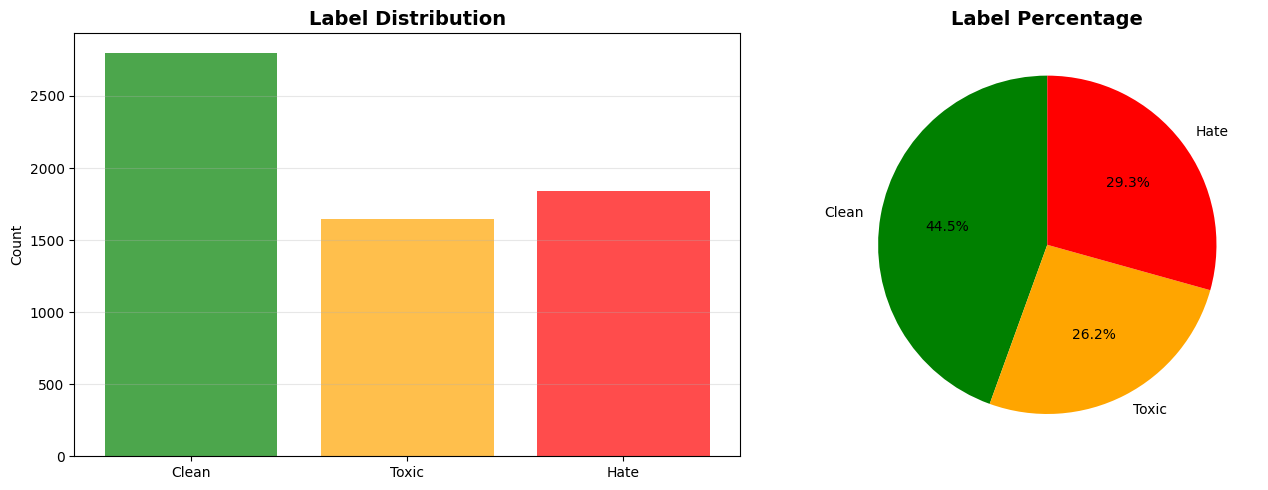


✅ Visualization saved to videberta_toxic_model/data_distribution.png


In [20]:
# Cell 6: Visualize data
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

print("="*60)
print("DATA VISUALIZATION")
print("="*60)

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts = df['label'].value_counts().sort_index()
label_names = {0: 'Clean', 1: 'Toxic', 2: 'Hate'}
colors = ['green', 'orange', 'red']

axes[0].bar([label_names[i] for i in label_counts.index], 
            label_counts.values, color=colors, alpha=0.7)
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(label_counts.values, labels=[label_names[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Label Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/data_distribution.png', dpi=150)
plt.show()

print(f"\n✅ Visualization saved to {Config.OUTPUT_DIR}/data_distribution.png")


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Prepare Data
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔧 PREPARING DATA")
print("="*80)

texts = df[text_col].fillna('').astype(str).tolist()
labels = df[label_col].astype(int).tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.15,
    random_state=Config.SEED,
    stratify=labels
)

print(f"📊 Train: {len(train_texts)} | Val: {len(val_texts)}")
print("✅ Data prepared!")

🔧 PREPARING DATA
📊 Train: 5342 | Val: 943
✅ Data prepared!


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Load Tokenizer & Add Special Tokens
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📥 LOADING TOKENIZER & ADDING SPECIAL TOKENS")
print("="*80)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
print(f"✅ Tokenizer loaded: {Config.MODEL_NAME}")
print(f"   Vocab size (before): {tokenizer.vocab_size}")

# Add special tokens
special_tokens_dict = {
    'additional_special_tokens': Config.SPECIAL_TOKENS
}
num_added = tokenizer.add_special_tokens(special_tokens_dict)
print(f"\n✅ Added {num_added} special tokens:")
for token in Config.SPECIAL_TOKENS:
    print(f"   - {token}")

print(f"\n✅ Vocab size (after): {len(tokenizer)}")

# Test tokenization
test_text = "học sinh giỏi <sep> <emo_pos> <person> bú fame"
tokens = tokenizer.tokenize(test_text)
print(f"\n🔍 TEST TOKENIZATION:")
print(f"   Text: {test_text}")
print(f"   Tokens: {tokens[:15]}...")
print(f"   Token count: {len(tokens)}")


📥 LOADING TOKENIZER & ADDING SPECIAL TOKENS
✅ Tokenizer loaded: Fsoft-AIC/videberta-base
   Vocab size (before): 128000

✅ Added 5 special tokens:
   - <sep>
   - <emo_pos>
   - <emo_neg>
   - <person>
   - <user>

✅ Vocab size (after): 128005

🔍 TEST TOKENIZATION:
   Text: học sinh giỏi <sep> <emo_pos> <person> bú fame
   Tokens: ['▁học', '▁sinh', '▁giỏi', '<sep>', '<emo_pos>', '<person>', '▁bú', '▁', 'fame']...
   Token count: 9


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Create Dataset
# ═══════════════════════════════════════════════════════════════════════════════

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Raw text with semantic tokens - no preprocessing needed!
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer, Config.MAX_LENGTH)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer, Config.MAX_LENGTH)

print(f"✅ Train dataset: {len(train_dataset)} | Val dataset: {len(val_dataset)}")
print(f"✅ Max length: {Config.MAX_LENGTH} tokens")
print(f"✅ Format: RAW TEXT + SEMANTIC TOKENS")


✅ Train dataset: 5342 | Val dataset: 943
✅ Max length: 512 tokens
✅ Format: RAW TEXT + SEMANTIC TOKENS


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10: Create DataLoaders & Class Weights
# ═══════════════════════════════════════════════════════════════════════════════

# DataLoaders - num_workers=0 để tránh lỗi multiprocessing trên Kaggle
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(Config.DEVICE)

print(f"⚖️ Class weights: {class_weights.cpu().numpy()}")


✅ Train batches: 668 | Val batches: 59
⚖️ Class weights: [0.7494388 1.2719047 1.1370796]


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: Load Model & Resize Embeddings
# ═══════════════════════════════════════════════════════════════════════════════

print("="*60)
print("LOADING MODEL")
print("="*60)

model = AutoModelForSequenceClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

# Resize embeddings for special tokens
model.resize_token_embeddings(len(tokenizer))

# ✅ THÊM DÒNG NÀY - Enable gradient checkpointing
model.gradient_checkpointing_enable()
print("✅ Gradient checkpointing enabled (saves ~40% memory)")

model = model.to(Config.DEVICE)

print(f"\n✅ Model loaded: {Config.MODEL_NAME}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"   Embeddings size: {model.get_input_embeddings().weight.shape}")
print(f"   Device: {next(model.parameters()).device}")

LOADING MODEL


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at Fsoft-AIC/videberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Gradient checkpointing enabled (saves ~40% memory)

✅ Model loaded: Fsoft-AIC/videberta-base
   Parameters: 184,351,491
   Trainable: 184,351,491
   Embeddings size: torch.Size([128005, 768])
   Device: cuda:0


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: Training Functions
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: Setup Training (Optimizer, Scheduler, Loss)
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("SETUP TRAINING")
print("="*80)

# Class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(Config.DEVICE)

print(f"⚖️ Class weights: {class_weights.cpu().numpy()}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=Config.LABEL_SMOOTHING
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

# Scheduler
total_steps = len(train_loader) * Config.EPOCHS // Config.GRADIENT_ACCUMULATION_STEPS
warmup_steps = int(total_steps * Config.WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✅ Optimizer: AdamW (lr={Config.LEARNING_RATE})")
print(f"✅ Loss: CrossEntropyLoss with class weights")
print(f"✅ Scheduler: Cosine warmup ({warmup_steps}/{total_steps} steps)")


SETUP TRAINING
⚖️ Class weights: [0.7494388 1.2719047 1.1370796]
✅ Optimizer: AdamW (lr=2e-05)
✅ Loss: CrossEntropyLoss with class weights
✅ Scheduler: Cosine warmup (83/835 steps)


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: Training Functions
# ═══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, accumulation_steps):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for i, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels) / accumulation_steps
        loss.backward()
        
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item() * accumulation_steps})
    
    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, f1


def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'loss': avg_loss,
        'f1': f1_score(all_labels, all_preds, average='macro'),
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro'),
        'recall': recall_score(all_labels, all_preds, average='macro')
    }
    
    return metrics, all_preds, all_labels, all_probs

print("✅ Training functions defined!")


✅ Training functions defined!


NameError: name 'history' is not defined

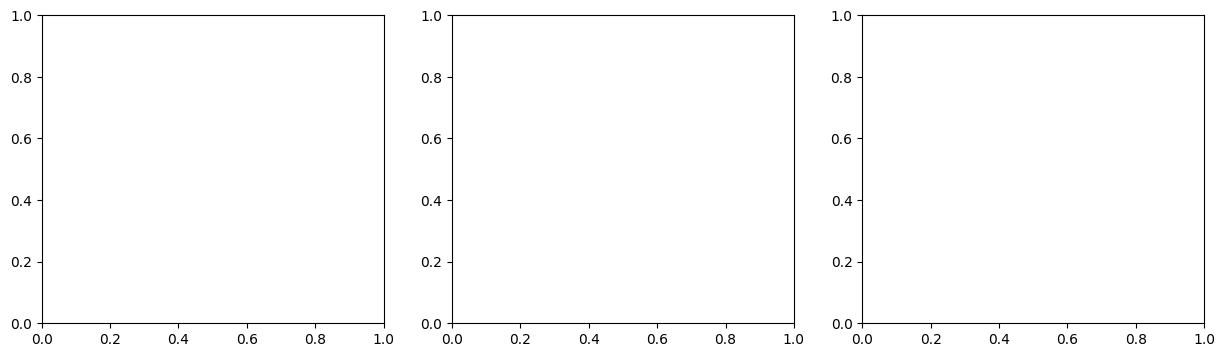

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: Plot Training History
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_f1'], label='Train', marker='o')
axes[1].plot(history['val_f1'], label='Val', marker='s')
axes[1].axhline(y=0.76, color='r', linestyle='--', label='Target (ViDeBERTa)')
axes[1].axhline(y=0.72, color='orange', linestyle=':', label='PhoBERT baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 (macro)')
axes[1].set_title('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_accuracy'], label='Val', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15: Final Evaluation & Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 FINAL EVALUATION")
print("="*80)

final_metrics, final_preds, final_true, final_probs = eval_epoch(
    model, val_loader, criterion, Config.DEVICE
)

print(f"\n🎯 FINAL METRICS:")
print(f"   F1 (macro): {final_metrics['f1_macro']:.4f}")
print(f"   F1 (weighted): {final_metrics['f1_weighted']:.4f}")
print(f"   Accuracy: {final_metrics['accuracy']:.4f}")
print(f"   Precision: {final_metrics['precision']:.4f}")
print(f"   Recall: {final_metrics['recall']:.4f}")

print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(final_true, final_preds, target_names=['Clean', 'Toxic', 'Hate']))

cm = confusion_matrix(final_true, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Toxic', 'Hate'],
            yticklabels=['Clean', 'Toxic', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ViDeBERTa')
plt.savefig(f'{Config.OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 16: Error Analysis & Export
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔍 ERROR ANALYSIS")
print("="*80)

label_names_map = {0: 'Clean', 1: 'Toxic', 2: 'Hate'}

error_data = []
for i, (text, true_label, pred_label, probs) in enumerate(zip(val_texts, final_true, final_preds, final_probs)):
    is_error = true_label != pred_label
    error_data.append({
        'id': i + 1,
        'text': text,
        'true_label': int(true_label),
        'true_label_name': label_names_map[int(true_label)],
        'pred_label': int(pred_label),
        'pred_label_name': label_names_map[int(pred_label)],
        'is_error': is_error,
        'error_type': f"{int(true_label)}→{int(pred_label)}" if is_error else 'Correct',
        'confidence': float(probs[pred_label]),
        'conf_clean': float(probs[0]),
        'conf_toxic': float(probs[1]),
        'conf_hate': float(probs[2])
    })

df_results = pd.DataFrame(error_data)
df_errors = df_results[df_results['is_error'] == True].copy()

total_errors = len(df_errors)
print(f"\n📊 Errors: {total_errors} / {len(df_results)} ({total_errors/len(df_results)*100:.1f}%)")

print(f"\n📊 ERROR BREAKDOWN:")
for et, cnt in df_errors['error_type'].value_counts().items():
    print(f"   {et}: {cnt}")

# Save errors to Excel
error_file = f'{Config.OUTPUT_DIR}/videberta_errors.xlsx'
df_errors.to_excel(error_file, index=False)
print(f"\n💾 Errors saved: {error_file}")

# Show top errors
print(f"\n🔥 TOP 10 HIGH-CONFIDENCE ERRORS:")
high_conf_errors = df_errors.sort_values('confidence', ascending=False).head(10)
for idx, row in high_conf_errors.iterrows():
    print(f"\n[{row['error_type']}] Conf: {row['confidence']:.2%}")
    print(f"   {row['text'][:80]}...")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 17: Save Model
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("💾 SAVING MODEL")
print("="*80)

os.makedirs(Config.MODEL_SAVE_PATH, exist_ok=True)

model.save_pretrained(Config.MODEL_SAVE_PATH)
tokenizer.save_pretrained(Config.MODEL_SAVE_PATH)

import json
config_dict = {
    'model_name': Config.MODEL_NAME,
    'num_labels': Config.NUM_LABELS,
    'max_length': Config.MAX_LENGTH,
    'best_f1': best_f1,
    'best_epoch': best_epoch,
    'final_metrics': final_metrics,
    'data_file': Config.DATA_PATH,
    'special_tokens': Config.SPECIAL_TOKENS,
    'format': 'RAW_TEXT_WITH_SEMANTIC_TOKENS'
}
with open(f'{Config.MODEL_SAVE_PATH}/training_config.json', 'w') as f:
    json.dump(config_dict, f, indent=2, default=str)

pd.DataFrame(history).to_csv(f'{Config.MODEL_SAVE_PATH}/training_history.csv', index=False)

print(f"\n✅ Model saved to: {Config.MODEL_SAVE_PATH}")

print(f"\n📁 OUTPUT FILES:")
for f in os.listdir(Config.OUTPUT_DIR):
    fpath = os.path.join(Config.OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024 / 1024
        print(f"   {f} ({size:.2f} MB)")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 18: Test Inference
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🧪 TEST INFERENCE")
print("="*80)

def predict(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(text, max_length=Config.MAX_LENGTH, padding='max_length', 
                        truncation=True, return_tensors='pt')
    with torch.no_grad():
        outputs = model(encoding['input_ids'].to(device), encoding['attention_mask'].to(device))
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return pred, probs[0].cpu().numpy()

# Test samples - RAW TEXT (no segmentation!)
test_samples = [
    "video hay quá, cảm ơn bạn",
    "thằng ngu, mày biết gì",
    "đồ con chó, cút đi",
    "sản phẩm chất vcl",
    "bọn bắc kỳ toàn lừa đảo",
    "học sinh giỏi bú fame",
    "awai x <user> - body shaming ? <sep> tôi cũng hỏi thế",
    "boy phố gãy cánh <emo_pos> <sep> <person> hôm sau"
]

label_names_list = ['Clean', 'Toxic', 'Hate']
print("\n🔮 PREDICTIONS:")
for text in test_samples:
    pred, probs = predict(text, model, tokenizer, Config.DEVICE)
    print(f"\n📝 {text[:70]}...")
    print(f"   → {label_names_list[pred]} ({probs[pred]:.2%})")
    if '<sep>' in text:
        print(f"   ✅ Has semantic separator")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 19: Summary
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 TRAINING SUMMARY - ViDeBERTa")
print("="*80)

print(f"""
📊 DATASET: {len(texts)} samples (Train: {len(train_texts)} | Val: {len(val_texts)})
   Format: RAW TEXT + SEMANTIC TOKENS ✅
   Special tokens: {', '.join(Config.SPECIAL_TOKENS)}

🔧 MODEL: {Config.MODEL_NAME}
   Parameters: {total_params:,} (vs PhoBERT 135M)
   Max Length: {Config.MAX_LENGTH} tokens (vs PhoBERT 256)
   Vocab size: {len(tokenizer)} (with special tokens)

📈 TRAINING:
   Epochs: {len(history['train_loss'])} (best at {best_epoch})
   Batch: {Config.BATCH_SIZE} x {Config.GRADIENT_ACCUMULATION_STEPS}

🎯 RESULTS:
   Best F1 (macro): {best_f1:.4f}
   Final Accuracy: {final_metrics['accuracy']:.4f}
   Errors: {total_errors} ({total_errors/len(df_results)*100:.1f}%)

💾 OUTPUT: {Config.OUTPUT_DIR}
   - videberta_toxic_model/
   - training_history.png
   - confusion_matrix.png
   - videberta_errors.xlsx

{'✅ TARGET ACHIEVED! (>0.76)' if best_f1 >= 0.76 else '⚠️ Target (0.76) not reached' if best_f1 >= 0.72 else '❌ Below baseline (0.72)'}

📊 COMPARISON vs PhoBERT:
   PhoBERT expected: 0.72-0.76
   ViDeBERTa actual: {best_f1:.4f}
   Improvement: {'+' if best_f1 >= 0.72 else ''}{(best_f1 - 0.74) * 100:.1f}% vs PhoBERT baseline
""")

print("="*80)
print("✅ NOTEBOOK COMPLETE!")
print("="*80)
print("\n📥 To download model: Click 'Output' tab → Download files")
print("\n✅ ADVANTAGES of ViDeBERTa:")
print("   1. No word segmentation needed (simpler pipeline)")
print("   2. Longer context (512 vs 256 tokens)")
print("   3. Semantic tokens (<sep>, <emo_pos>, etc.)")
print("   4. Better for social media text")
print("   5. Smaller model (86M vs 135M params)")
print("\n⚠️ LƯU Ý: Khi inference với text MỚI:")
print("   - NO need to segment (raw text)")
print("   - Add <sep> between title and comment if applicable")
print("   - Special tokens will be recognized automatically")
